# Classical

In [1]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from matplotlib import pyplot as plt
%matplotlib inline
import pandas as pd
pd.set_option('display.max_columns', None)
import seaborn as sns
import numpy as np
import prince
from ucimlrepo import fetch_ucirepo
from QuECOC import build_ecoc_matrix

In [18]:
lab_train = pd.read_csv('lab1-train-processed.csv')
lab_test = pd.read_csv('lab1-test-processed.csv')

display(lab_train)
display(lab_test)

y_train = lab_train['class']
y_test = lab_test['class']
X_train = lab_train.drop('class', axis=1)
X_test = lab_test.drop('class', axis=1)

top_cols = [col for col in X_train.columns if col.startswith('X')]
famd_cols = [col for col in X_train.columns if col.startswith('C')]

,class,X2,C0,X6,C1,X10,C2,X17,C3,X3,C4,X4,C5,X7,C6,X5_1,C7,X13,C8,X15_1,C9
0,6,133.907314,-1.468208,2.989235,0.276903,1.745602,-1.991880,18.008365,1.665992,3.000000,0.229429,0.625350,0.430481,2.923792,-0.388358,0,-0.027717,1.536555,0.191164,0,0.392011
1,4,82.365608,0.714526,1.810804,-0.618230,1.608400,-1.650259,22.339190,-1.390567,1.000000,0.296710,2.000000,1.706740,2.598632,1.324411,0,-0.891510,0.292093,0.010644,0,0.161591
2,5,121.134488,-2.238483,2.811050,0.281797,1.867410,-0.672576,23.274485,0.569318,2.657720,0.563710,0.000000,-0.540056,2.104696,-0.125796,1,0.702596,0.870056,-0.008144,0,-0.410528
3,3,79.125521,0.405247,2.000000,1.650545,1.800000,-0.510070,17.652645,-1.338986,1.000000,1.324808,1.000000,-0.165750,2.000000,0.540286,1,0.183907,2.000000,-0.076974,1,-0.326369
4,5,118.193323,-2.002027,2.191108,0.604417,1.788586,-0.415796,24.566325,0.107035,2.993856,0.729268,0.145284,-0.443735,2.444917,-0.272059,1,0.404912,1.388962,-0.046416,0,-0.086728
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1683,3,66.859042,1.451516,2.000000,0.303109,1.640000,0.447478,21.226280,-1.254997,3.000000,-1.246056,1.000000,-0.086139,1.000000,-0.521961,1,-0.363859,0.000000,-0.504150,0,-1.602967
1684,4,98.739188,-0.881631,2.000000,1.897943,1.732694,-0.426703,21.494374,-1.222413,2.993623,-0.707082,1.529423,0.645786,2.326635,-0.720979,1,-1.006865,2.236586,0.317045,0,-0.150458
1685,4,95.973811,-1.011257,2.000000,2.155115,1.741353,-0.333581,21.005434,-0.944677,3.000000,-0.354342,1.229474,0.727815,2.697661,-1.109787,1,-0.995599,2.614909,0.431379,0,-0.052324
1686,0,79.634810,-1.090697,1.993101,0.495533,1.745950,-0.022242,24.969213,-0.348468,3.171082,0.713230,0.022245,-0.693482,2.364498,-0.282761,1,0.378846,1.224743,-0.208985,0,0.082620


,class,X2,C0,X6,C1,X10,C2,X17,C3,X3,C4,X4,C5,X7,C6,X5_1,C7,X13,C8,X15_1,C9
0,0,65.517027,0.484487,2.374640,-1.847356,1.449559,1.590055,36.591143,0.396030,3.000000,-0.189425,0.480813,0.340385,2.000000,-1.107690,0,-0.227402,2.892922,0.179947,0,1.047396
1,4,80.321076,0.109128,2.766320,-3.276887,1.582523,2.075080,42.412773,-0.221815,1.317884,-0.121852,0.000000,1.570310,1.967408,-1.178837,0,-0.372068,0.990642,0.527927,0,-0.123479
2,6,103.939346,0.073094,3.000000,-1.897598,1.617390,-1.372753,24.228630,0.688670,3.000000,-0.626943,0.541309,-0.320001,1.292479,0.558842,0,0.421557,0.000000,-0.395995,0,-0.056059
3,3,64.881769,-0.796613,3.000000,1.193776,1.780000,1.134938,24.192968,0.908599,3.000000,-0.281191,1.000000,0.873024,2.000000,2.358295,1,-2.152621,1.000000,0.820595,0,2.345712
4,4,103.919796,-1.670365,2.253707,0.339208,1.785718,-0.616425,23.199143,-0.033524,3.000000,0.776164,0.175694,-0.464756,2.524432,0.078508,1,0.435049,0.582160,-0.180257,0,0.012671
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
418,6,106.455606,-0.521648,3.009608,-1.567272,1.629191,-1.414409,27.070496,1.220609,3.000000,0.150220,0.555468,0.401723,2.654702,0.222386,0,0.132335,0.000000,-0.099324,0,0.446954
419,3,60.350897,0.979537,2.000000,0.074900,1.650000,0.661700,22.742513,-0.687676,3.000000,-0.106647,0.000000,0.040351,2.000000,-1.063919,1,-0.124470,0.000000,-0.350357,0,-1.211942
420,4,95.104136,-0.641643,2.000000,1.167839,1.701986,-0.225637,22.698244,-1.236276,3.000000,-0.591072,1.066603,0.349936,2.021270,-0.624453,1,-0.686549,1.814869,0.152797,0,-0.284635
421,4,80.293832,0.202996,2.000000,-3.692421,1.529060,1.813763,40.067806,-0.553698,3.000000,-0.338952,0.000000,-0.623399,1.000000,0.189557,0,0.530507,0.000000,-0.555358,0,0.418316


In [207]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train[famd_cols[:2]])
X_test_scaled = scaler.transform(X_test[famd_cols[:2]])

lr = LogisticRegression(max_iter=1000, class_weight='balanced')
lr.fit(X_train_scaled, y_train)
y_pred = lr.predict(X_test_scaled)
print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.21      0.14      0.17        58
           1       0.11      0.10      0.11        58
           2       0.43      0.67      0.52        54
           3       0.33      0.19      0.24        58
           4       0.13      0.03      0.05        70
           5       0.41      0.77      0.53        60
           6       0.51      0.66      0.58        65

    accuracy                           0.36       423
   macro avg       0.30      0.36      0.31       423
weighted avg       0.30      0.36      0.31       423



In [208]:
svc = SVC(kernel='rbf', class_weight='balanced')
svc.fit(X_train_scaled, y_train)
y_pred = svc.predict(X_test_scaled)
print("SVC Classification Report:")
print(classification_report(y_test, y_pred))

SVC Classification Report:
              precision    recall  f1-score   support

           0       0.20      0.05      0.08        58
           1       0.31      0.28      0.29        58
           2       0.45      0.74      0.56        54
           3       0.47      0.38      0.42        58
           4       0.49      0.40      0.44        70
           5       0.59      0.75      0.66        60
           6       0.65      0.88      0.75        65

    accuracy                           0.50       423
   macro avg       0.45      0.50      0.46       423
weighted avg       0.46      0.50      0.46       423



In [210]:
ecoc = build_ecoc_matrix(7, 14)

final_preds = np.array([[0] * ecoc.shape[1]] * len(y_test))
for i, code in enumerate(ecoc):
    clf = LogisticRegression(max_iter=1000, class_weight='balanced')
    clf.fit(X_train_scaled, y_train.apply(lambda x: code[x]))
    y_pred = clf.predict(X_test_scaled)

    # # Individual classification report for each binary classifier
    # print(f"Classifier {i+1} (Code: {code}):")
    # print(classification_report(y_test.apply(lambda x: code[x]), y_pred))

    for j, pred in enumerate(y_pred):
        final_preds[j][code == pred] += 1

final_preds = np.argmax(final_preds, axis=1)
print("Logistic Regression Ensemble Classification Report:")
print(classification_report(y_test, final_preds, zero_division=0))

Logistic Regression Ensemble Classification Report:
              precision    recall  f1-score   support

           0       0.22      0.10      0.14        58
           1       1.00      0.02      0.03        58
           2       0.32      0.78      0.45        54
           3       0.00      0.00      0.00        58
           4       0.00      0.00      0.00        70
           5       0.26      0.73      0.39        60
           6       0.41      0.57      0.47        65

    accuracy                           0.31       423
   macro avg       0.32      0.31      0.21       423
weighted avg       0.31      0.31      0.21       423



In [211]:
ecoc = build_ecoc_matrix(7, 14)

final_preds = np.array([[0] * ecoc.shape[1]] * len(y_test))
for i, code in enumerate(ecoc):
    clf = SVC(kernel='rbf', class_weight='balanced')
    clf.fit(X_train_scaled, y_train.apply(lambda x: code[x]))
    y_pred = clf.predict(X_test_scaled)

    # # Individual classification report for each binary classifier
    # print(f"Classifier {i+1} (Code: {code}):")
    # print(classification_report(y_test.apply(lambda x: code[x]), y_pred))

    for j, pred in enumerate(y_pred):
        final_preds[j][code == pred] += 1

final_preds = np.argmax(final_preds, axis=1)
print("SVC Ensemble Classification Report:")
print(classification_report(y_test, final_preds, zero_division=0))

SVC Ensemble Classification Report:
              precision    recall  f1-score   support

           0       0.34      0.28      0.30        58
           1       0.18      0.03      0.06        58
           2       0.58      0.61      0.59        54
           3       0.54      0.52      0.53        58
           4       0.43      0.49      0.46        70
           5       0.56      0.73      0.63        60
           6       0.60      0.86      0.70        65

    accuracy                           0.51       423
   macro avg       0.46      0.50      0.47       423
weighted avg       0.46      0.51      0.47       423



# Quantum

In [2]:
import pennylane as qml
from pennylane import numpy as np
from pennylane.templates import IQPEmbedding, StronglyEntanglingLayers
import torch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from QuECOC import QuECOC, BinaryVQC

plt.rcParams["figure.figsize"] = (12, 6)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE = "cpu"

print(f"Using device: {DEVICE}\n")
qml.about()

Using device: cpu

Name: pennylane
Version: 0.45.0
Summary: PennyLane is a cross-platform Python library for quantum computing, quantum machine learning, and quantum chemistry. Train a quantum computer the same way as a neural network.
Home-page: 
Author: 
License: 
Location: /home/edwar/.pyenv/versions/3.14.5/lib/python3.14/site-packages
Platform info:           Linux-6.6.87.2-microsoft-standard-WSL2-x86_64-with-glibc2.39
Python version:          3.14.5
Numpy version:           2.4.6
Scipy version:           1.17.1
JAX version:             None
Catalyst version:        None
Installed devices:
- lightning.gpu (pennylane_lightning_gpu-0.45.0)
- default.clifford (pennylane-0.45.0)
- default.gaussian (pennylane-0.45.0)
- default.mixed (pennylane-0.45.0)
- default.qubit (pennylane-0.45.0)
- default.qutrit (pennylane-0.45.0)
- default.qutrit.mixed (pennylane-0.45.0)
- default.tensor (pennylane-0.45.0)
- null.qubit (pennylane-0.45.0)
- reference.qubit (pennylane-0.45.0)
- lightning.qubit (pe

In [3]:
n_qubits = 2
n_layers = 2

if DEVICE == "cuda":
    dev = qml.device("lightning.gpu", wires=n_qubits)
else:
    dev = qml.device("default.qubit", wires=n_qubits)
    
scaler = MinMaxScaler(feature_range=(0, np.pi))

<default.qubit device (wires=2) at 0x704730d134d0>


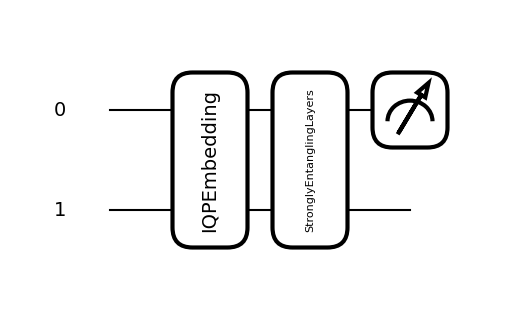

In [4]:
@qml.qnode(dev, interface='torch', diff_method='best')
def circuit(inputs: torch.Tensor, weights: torch.Tensor) -> qml.measurements.ProbabilityMP:
    IQPEmbedding(inputs, wires=range(n_qubits), n_repeats=2)
    StronglyEntanglingLayers(weights, wires=range(n_qubits))

    return qml.probs(wires=[0])

weight_shapes = {
    "weights": (n_layers, n_qubits, 3)
}

qml.draw_mpl(circuit)(np.zeros(n_qubits), np.zeros(weight_shapes["weights"]))
print(circuit.device)

qlayer = qml.qnn.TorchLayer(circuit, weight_shapes=weight_shapes)

In [5]:
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17)

X = breast_cancer_wisconsin_diagnostic.data.features
y = breast_cancer_wisconsin_diagnostic.data.targets
label_names = sorted(y[y.columns[0]].unique())
label_to_int = {label: idx for idx, label in enumerate(label_names)}
int_to_label = {idx: label for idx, label in enumerate(label_names)}
print(f"Label mapping: {label_to_int}")
y = y[y.columns[0]].map(label_to_int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2, stratify=y)

pca = prince.PCA(n_components=2, n_iter=5, random_state=2)
X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)

X_tr = torch.tensor(scaler.fit_transform(X_train), dtype=torch.float32).to(DEVICE)
X_te = torch.tensor(scaler.transform(X_test), dtype=torch.float32).to(DEVICE)
y_tr = torch.tensor(y_train.values, dtype=torch.long).to(DEVICE)
y_te = torch.tensor(y_test.values, dtype=torch.long).to(DEVICE)

trainloader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=32, shuffle=True)
testloader = DataLoader(TensorDataset(X_te, y_te), batch_size=32, shuffle=False)

Label mapping: {'B': 0, 'M': 1}


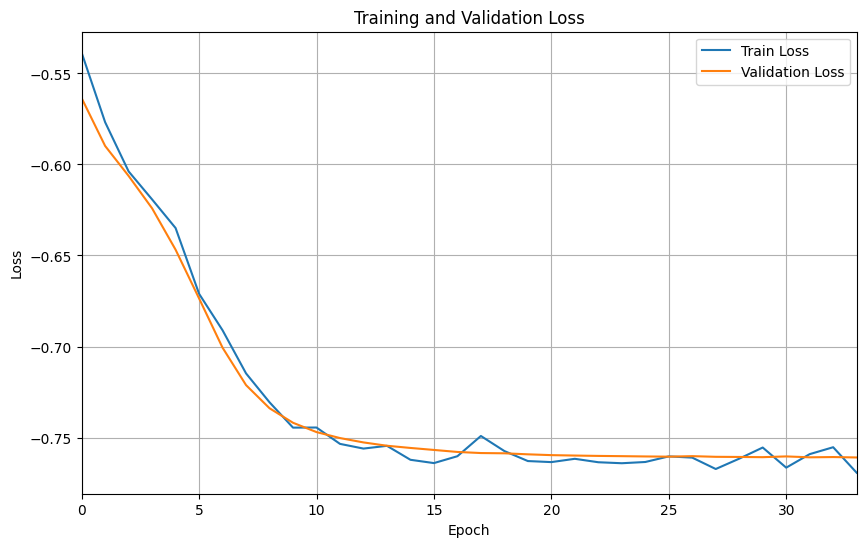

[Epoch 34/100] Train Loss: -0.7693 | Val Loss: -0.7609 | Val Acc: 0.877
Early stopping at epoch 34
Total training time: 6.63 seconds


In [6]:
model = BinaryVQC(qlayer).to(DEVICE)
model.fit(trainloader, testloader)

In [7]:
train_score = model.score(X_tr, y_tr)

print(f"Training Accuracy: {train_score:.2f}")
print("Classification Report:\n", classification_report(y_te, model.predict(X_te), zero_division=0))

Training Accuracy: 0.86
Classification Report:
               precision    recall  f1-score   support

           0       0.84      1.00      0.91        72
           1       1.00      0.67      0.80        42

    accuracy                           0.88       114
   macro avg       0.92      0.83      0.86       114
weighted avg       0.90      0.88      0.87       114



## Ensemble

In [4]:
iris = fetch_ucirepo(id=53)

X = iris.data.features
y = iris.data.targets
label_names = sorted(y[y.columns[0]].unique())
label_to_int = {label: idx for idx, label in enumerate(label_names)}
int_to_label = {idx: label for idx, label in enumerate(label_names)}
print(f"Label mapping: {label_to_int}")
y = y[y.columns[0]].map(label_to_int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2, stratify=y)

pca = prince.PCA(n_components=2, n_iter=5, random_state=2)
X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Label mapping: {'Iris-setosa': 0, 'Iris-versicolor': 1, 'Iris-virginica': 2}


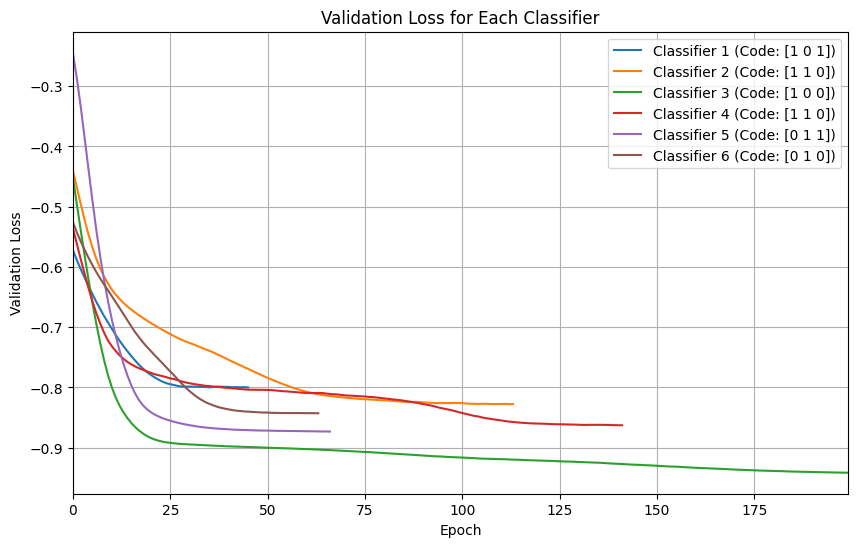

Total training time after fitting 6 classifiers: 67.80 seconds


In [5]:
ens = QuECOC().to(DEVICE)
ens.fit(X_train_scaled, y_train, X_test_scaled, y_test, epochs=200, plot=True, verbose=True)

In [6]:
train_score = ens.score(X_train_scaled, y_train)

print(f"Training Accuracy: {train_score:.2f}")
print("Classification Report:\n", classification_report(y_test, ens.predict(X_test_scaled), zero_division=0))

Training Accuracy: 0.89
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.90      0.90      0.90        10
           2       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [4]:
lab_train = pd.read_csv('lab1-train-processed.csv')
lab_test = pd.read_csv('lab1-test-processed.csv')

y_train = lab_train['class']
y_test = lab_test['class']
X_train = lab_train.drop('class', axis=1)
X_test = lab_test.drop('class', axis=1)

top_cols = [col for col in X_train.columns if col.startswith('X')]
famd_cols = [col for col in X_train.columns if col.startswith('C')]

scaler = MinMaxScaler(feature_range=(0, np.pi))
X_train_scaled = scaler.fit_transform(X_train[famd_cols[:6]])
X_test_scaled = scaler.transform(X_test[famd_cols[:6]])

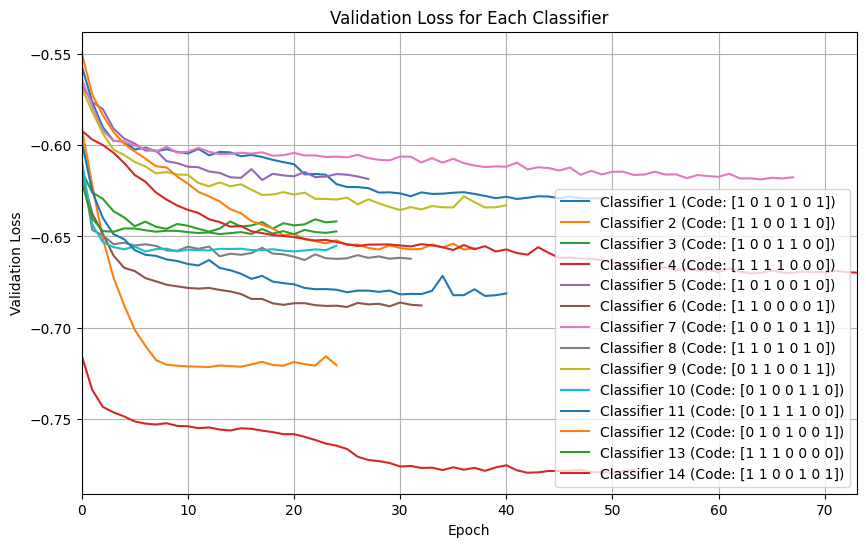

Total training time after fitting 14 classifiers: 416.73 seconds


In [5]:
ens = QuECOC(feats_per_qubit=3, reuploads=3, trainable_layers=[1,2,3]).to(DEVICE)
ens.fit(X_train_scaled, y_train, X_test_scaled, y_test, epochs=200, plot=True, verbose=True)

In [6]:
train_score = ens.score(X_train_scaled, y_train)

print(f"Training Accuracy: {train_score:.2f}")
print("Classification Report:\n", classification_report(y_test, ens.predict(X_test_scaled), zero_division=0))

Training Accuracy: 0.53
Classification Report:
               precision    recall  f1-score   support

           0       0.17      0.19      0.18        58
           1       0.21      0.09      0.12        58
           2       0.62      0.54      0.57        54
           3       0.54      0.36      0.43        58
           4       0.33      0.47      0.39        70
           5       0.55      0.75      0.63        60
           6       0.96      1.00      0.98        65

    accuracy                           0.49       423
   macro avg       0.48      0.49      0.47       423
weighted avg       0.48      0.49      0.48       423



In [ ]:
feats_per_qubit_opts = [1, 2, 3]
reuploads_opts = [2, 3]
entangle_between_reuploads_opts = [True, False]
trainable_layers_opts = [2, 3]

sweep_tests = []
for feats_per_qubit in feats_per_qubit_opts:
    for reuploads in reuploads_opts:
        for entangle_between_reuploads in entangle_between_reuploads_opts:
            # for trainable_layers in trainable_layers_opts:
            #     sweep_tests.append({
            #         "feats_per_qubit": feats_per_qubit,
            #         "reuploads": reuploads,
            #         "entangle_between_reuploads": entangle_between_reuploads,
            #         "trainable_layers": trainable_layers,
            #     })

            if entangle_between_reuploads:
                sweep_tests.append({
                    "feats_per_qubit": feats_per_qubit,
                    "reuploads": reuploads,
                    "entangle_between_reuploads": entangle_between_reuploads,
                    "trainable_layers": list(range(1, reuploads + 1)),
                })
                sweep_tests.append({
                    "feats_per_qubit": feats_per_qubit,
                    "reuploads": reuploads,
                    "entangle_between_reuploads": entangle_between_reuploads,
                    "trainable_layers": list(range(reuploads, 0, -1)),
                })

print(f"Total tests to run: {len(sweep_tests)}")

for test_params in sweep_tests:
    print(test_params)

    feats = test_params["feats_per_qubit"] * 2
    X_train_scaled = scaler.fit_transform(X_train[famd_cols[:feats]])
    X_test_scaled = scaler.transform(X_test[famd_cols[:feats]])

    accs = []
    macro_f1s = []
    for _ in range(3):
        ens = QuECOC().to(DEVICE)
        ens.fit(X_train_scaled, y_train, X_test_scaled, y_test, epochs=100, plot=False, verbose=False)
        report = classification_report(y_test, ens.predict(X_test_scaled), zero_division=0, output_dict=True)
        accs.append(report["accuracy"] * 100)
        macro_f1s.append(report["macro avg"]["f1-score"] * 100)
    print(f"Avg Accuracy: {np.mean(accs):.2f} ± {np.std(accs):.2f}")
    print(f"Avg Macro F1-score: {np.mean(macro_f1s):.2f} ± {np.std(macro_f1s):.2f}")
    print("-" * 50)

Total tests to run: 12
{'feats_per_qubit': 1, 'reuploads': 2, 'entangle_between_reuploads': True, 'trainable_layers': [1, 2]}
Avg Accuracy: 32.55 ± 3.05
Avg Macro F1-score: 27.59 ± 3.75
--------------------------------------------------
{'feats_per_qubit': 1, 'reuploads': 2, 'entangle_between_reuploads': True, 'trainable_layers': [2, 1]}
Avg Accuracy: 29.79 ± 0.00
Avg Macro F1-score: 23.88 ± 0.49
--------------------------------------------------
{'feats_per_qubit': 1, 'reuploads': 3, 'entangle_between_reuploads': True, 'trainable_layers': [1, 2, 3]}
Avg Accuracy: 37.83 ± 0.39
Avg Macro F1-score: 34.36 ± 0.56
--------------------------------------------------
{'feats_per_qubit': 1, 'reuploads': 3, 'entangle_between_reuploads': True, 'trainable_layers': [3, 2, 1]}
Avg Accuracy: 36.80 ± 0.49
Avg Macro F1-score: 33.17 ± 0.59
--------------------------------------------------
{'feats_per_qubit': 2, 'reuploads': 2, 'entangle_between_reuploads': True, 'trainable_layers': [1, 2]}
Avg Accuracy

In [ ]:
feats_per_qubit_opts = [2, 3]
reuploads_opts = [3]
entangle_between_reuploads_opts = [True, False]
trainable_layers_opts = [2, 3]

sweep_tests = []
for feats_per_qubit in feats_per_qubit_opts:
    for reuploads in reuploads_opts:
        for entangle_between_reuploads in entangle_between_reuploads_opts:
            # for trainable_layers in trainable_layers_opts:
            #     sweep_tests.append({
            #         "feats_per_qubit": feats_per_qubit,
            #         "reuploads": reuploads,
            #         "entangle_between_reuploads": entangle_between_reuploads,
            #         "trainable_layers": trainable_layers,
            #     })

            if entangle_between_reuploads:
                sweep_tests.append({
                    "feats_per_qubit": feats_per_qubit,
                    "reuploads": reuploads,
                    "entangle_between_reuploads": entangle_between_reuploads,
                    "trainable_layers": list(range(1, reuploads + 1)),
                })
                sweep_tests.append({
                    "feats_per_qubit": feats_per_qubit,
                    "reuploads": reuploads,
                    "entangle_between_reuploads": entangle_between_reuploads,
                    "trainable_layers": list(range(reuploads, 0, -1)),
                })

print(f"Total tests to run: {len(sweep_tests)}")

for test_params in sweep_tests:
    print(test_params)

    feats = test_params["feats_per_qubit"] * 2
    X_train_scaled = scaler.fit_transform(X_train[famd_cols[:feats]])
    X_test_scaled = scaler.transform(X_test[famd_cols[:feats]])

    accs = []
    macro_f1s = []
    for _ in range(3):
        ens = QuECOC().to(DEVICE)
        ens.fit(X_train_scaled, y_train, X_test_scaled, y_test, epochs=100, plot=False, verbose=False)
        report = classification_report(y_test, ens.predict_proba(X_test_scaled).argmax(axis=1).tolist(), zero_division=0, output_dict=True)
        accs.append(report["accuracy"] * 100)
        macro_f1s.append(report["macro avg"]["f1-score"] * 100)
    print(f"Avg Accuracy: {np.mean(accs):.2f} ± {np.std(accs):.2f}")
    print(f"Avg Macro F1-score: {np.mean(macro_f1s):.2f} ± {np.std(macro_f1s):.2f}")
    print("-" * 50)

Total tests to run: 4
{'feats_per_qubit': 2, 'reuploads': 3, 'entangle_between_reuploads': True, 'trainable_layers': [1, 2, 3]}
Avg Accuracy: 50.83 ± 1.16
Avg Macro F1-score: 45.98 ± 1.36
--------------------------------------------------
{'feats_per_qubit': 2, 'reuploads': 3, 'entangle_between_reuploads': True, 'trainable_layers': [3, 2, 1]}
Avg Accuracy: 50.67 ± 1.69
Avg Macro F1-score: 44.83 ± 1.54
--------------------------------------------------
{'feats_per_qubit': 3, 'reuploads': 3, 'entangle_between_reuploads': True, 'trainable_layers': [1, 2, 3]}
Avg Accuracy: 48.70 ± 1.17
Avg Macro F1-score: 42.77 ± 1.13
--------------------------------------------------
{'feats_per_qubit': 3, 'reuploads': 3, 'entangle_between_reuploads': True, 'trainable_layers': [3, 2, 1]}
Avg Accuracy: 49.72 ± 0.80
Avg Macro F1-score: 44.62 ± 1.14
--------------------------------------------------
